In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
srate = 256
t = np.arange(0, 1, 1/srate)
N = len(t)

In [ ]:
x = np.sin(2 * np.pi * 5 * t)

In [ ]:
#Time Shifting: x[n-10]
k = 10
x_shift = np.roll(x, k)

In [ ]:
# Time Reversal: x[-n]
x_reverse = x[::-1]

In [ ]:
# Time Scaling: x[2n] (downsample by 2)
x_scale = x[::2]  # Take every second sample
t_scale = t[::2]

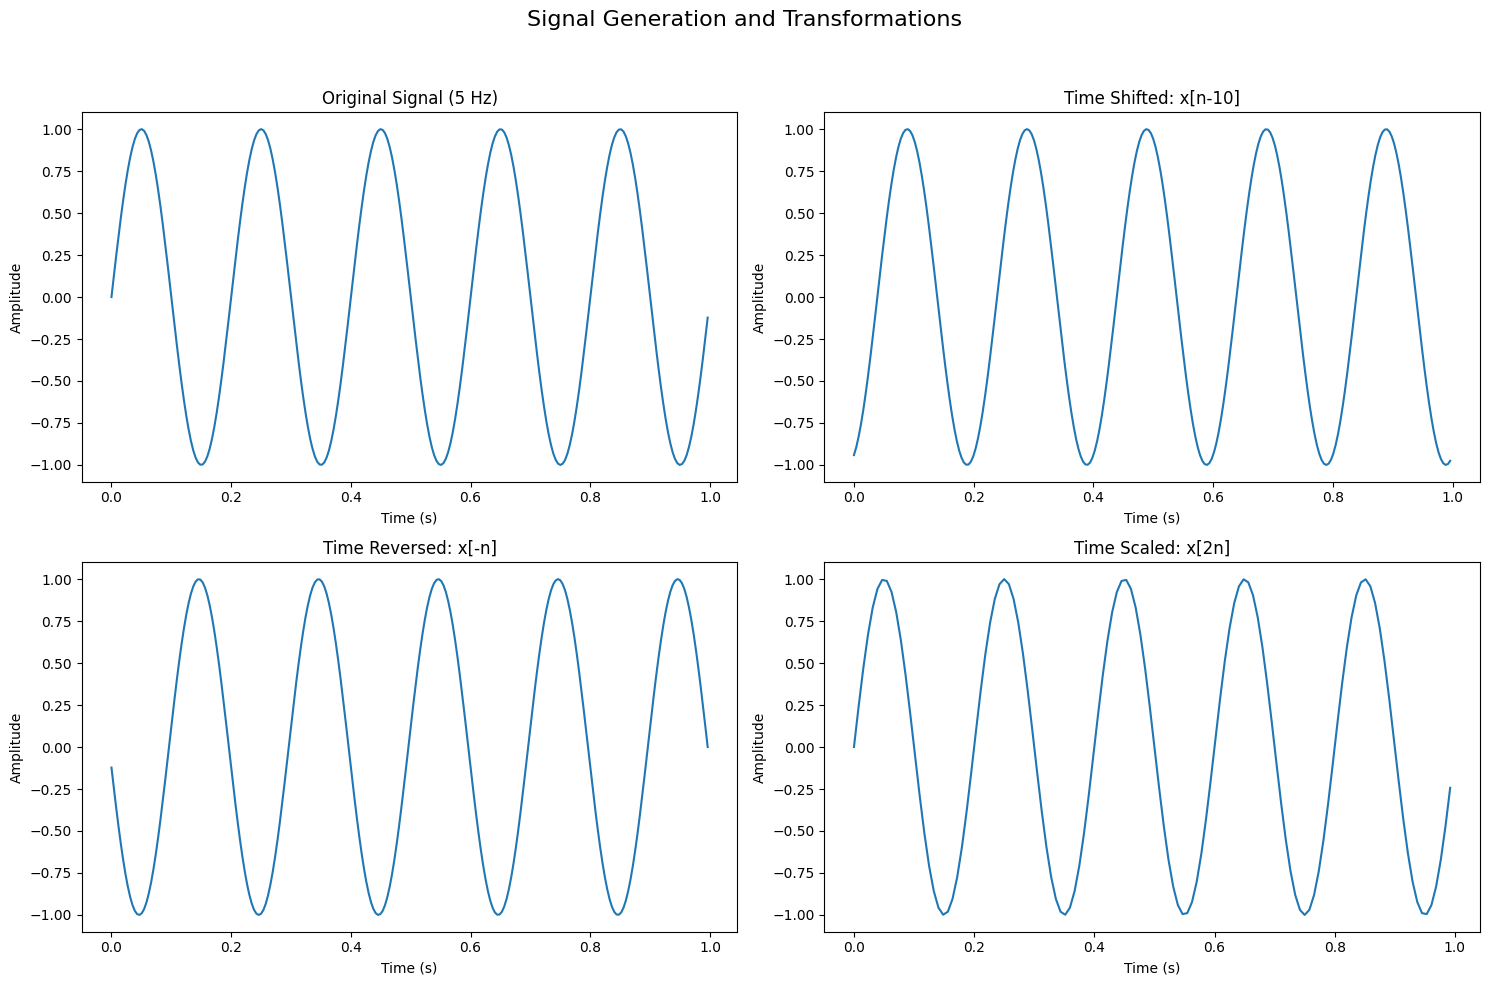

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle('Signal Generation and Transformations', fontsize=16)
plt.subplot(2, 2, 1)
plt.plot(t, x)
plt.title('Original Signal (5 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 2, 2)
plt.plot(t, x_shift)
plt.title('Time Shifted: x[n-10]')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2,2,3)
plt.plot(t,x_reverse)
plt.title('Time Reversed: x[-n]')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2,2,4)
plt.plot(t_scale, x_scale)
plt.title('Time Scaled: x[2n]')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

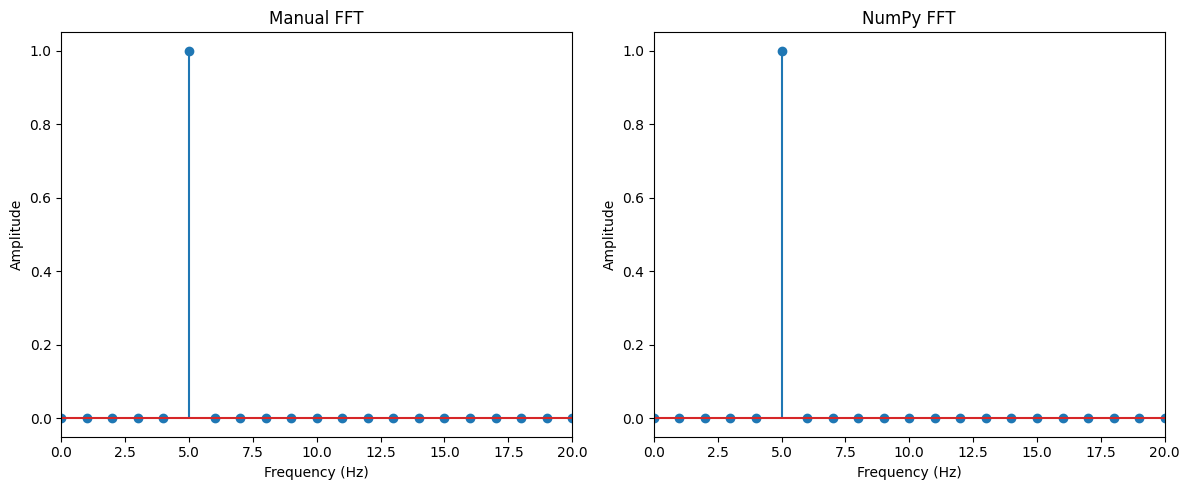

In [ ]:
X_manual=np.zeros(N, dtype=complex)
for k in range(N):
  for n in range(N):
    X_manual[k] +=x[n]*np.exp(-2j*np.pi*k*n/N)

amps_manual = 2*np.abs(X_manual)/N
freqs= np.linspace(0,srate/2,N//2+1)

x_fft = np.fft.fft(x)
amps_fft=2*np.abs(x_fft)/N

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.stem(freqs,amps_manual[:N//2+1])
plt.title('Manual FFT')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0,20)

plt.subplot(1,2,2)
plt.stem(freqs,amps_fft[:N//2+1])
plt.title('NumPy FFT')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0,20)
plt.tight_layout()
plt.show()

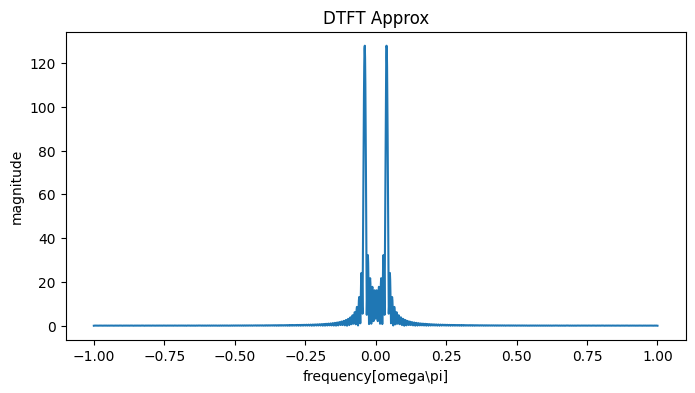

In [ ]:
w = np.linspace(-np.pi, np.pi, 2000)
X_dtft = np.zeros(len(w), dtype=complex)
for i, omega in enumerate(w):
    for n in range(N):
        X_dtft[i] += x[n] * np.exp(-1j * omega * n)

amps_dtft = np.abs(X_dtft)
plt.figure(figsize=(8,4))
plt.plot(w/np.pi , amps_dtft)
plt.title('DTFT Approx')
plt.xlabel('frequency[omega\pi]')
plt.ylabel('magnitude')
plt.show()

In [ ]:
start_time = time.time()
X_manual=np.zeros(N,dtype=complex)
for k in range(N):
  for n in range(N):
    X_manual[k] += x[n] * np.exp(-2j * np.pi *k*n/N)
manual_time =time.time() -start_time

start_time = time.time()
X_fft = np.fft.fft(x)
fft_time = time.time() - start_time

print(f"Manual FFT Time: {manual_time:.6f} seconds")
print(f"NumPy FFT Time: {fft_time:.6f} seconds")

Manual FFT Time: 0.142300 seconds
NumPy FFT Time: 0.000211 seconds


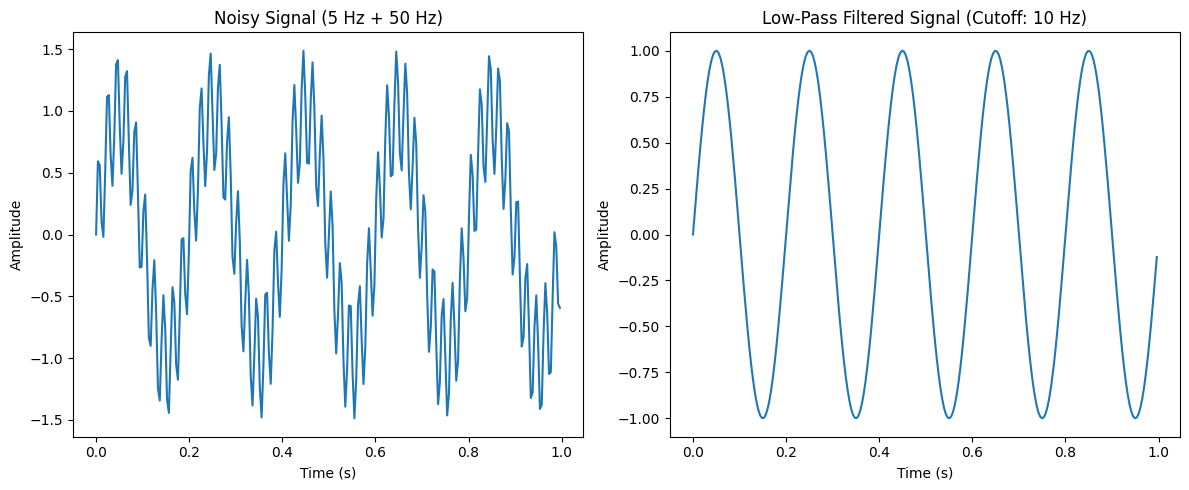

In [ ]:
x = np.sin(2 * np.pi * 5 * t)
x_noise = x + 0.5 * np.sin(2 * np.pi * 50 * t)
X_noise = np.fft.fft(x_noise)

cut = 10
cut_idx= int(cut *N/srate)
X_filtered =X_noise.copy()
X_filtered[cut_idx:N-cut_idx] = 0

x_filtered = np.fft.ifft(X_filtered)
x_filtered = np.real(x_filtered)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t, x_noise)
plt.title('Noisy Signal (5 Hz + 50 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(1, 2, 2)
plt.plot(t, x_filtered)
plt.title('Low-Pass Filtered Signal (Cut: 10 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()